In [572]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
# import warnings
# warnings.filterwarnings("ignore", category=FutureWarning)


In [573]:
# df = pd.read_spss(r"C:\Users\USER\Downloads\D00224_2\data.sav")
# df.to_csv('Dataset.csv', encoding='utf-8-sig', index=False)
df = pd.read_csv(r"C:\Users\No\Documents\GitHub\psychic-spoon\0 2025資料科學漫步\Dataset.csv")
# subset = df.

In [574]:
df.shape

(1004, 211)

In [575]:
df.columns.to_list()

['id',
 'startdate',
 'enddate',
 'duration_in_seconds',
 'q1',
 'q2',
 'q3',
 'q3_other',
 'q4',
 'q4_88_text',
 'q5_1',
 'q6_h',
 'q6_m',
 'q7_h',
 'q7_m',
 'q8_1',
 'q8_2',
 'q8_3',
 'q8_4',
 'q8_5',
 'q8_6',
 'q8_88',
 'q8_88_text',
 'q8_90',
 'q9_1',
 'q9_2',
 'q9_3',
 'q9_4',
 'q9_5',
 'q9_6',
 'q9_7',
 'q9_8',
 'q9_88',
 'q9_88_text',
 'q9_90',
 'q10_1',
 'q10_2',
 'q10_3',
 'q10_4',
 'q10_5',
 'q10_6',
 'q10_7',
 'q10_8',
 'q10_9',
 'q10_10',
 'q10_88',
 'q10_88_text',
 'q10_90',
 'q11_1',
 'q11_2',
 'q11_3',
 'q11_4',
 'q11_5',
 'q11_6',
 'q11_7',
 'q11_8',
 'q11_88',
 'q11_88_text',
 'q11_90',
 'q12_1',
 'q12_2',
 'q12_3',
 'q12_4',
 'q12_5',
 'q12_6',
 'q12_7',
 'q12_8',
 'q12_8_text',
 'q12_9',
 'q13_01_1',
 'q13_02_1',
 'q13_02_2',
 'q13_02_3',
 'q13_02_4',
 'q13_02_5',
 'q13_02_6',
 'q13_02_7',
 'q13_02_8',
 'q13_02_8_text',
 'q13_02_9',
 'q13_02_10',
 'q13_03_1',
 'q13_03_2',
 'q13_03_3',
 'q13_03_4',
 'q13_03_5',
 'q13_03_5_text',
 'q13_03_6',
 'q13_03_7',
 'q13_04_1',


---
---

### 篩選有效樣本中的注意力題答對的樣本

In [576]:
df = df[df['rq21a'] == '答對'].reset_index(drop=True)

In [577]:
df.shape

(685, 211)

---
---
## 基本資料

In [578]:
individual = df.iloc[:,4:59]
individual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 55 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   q1           685 non-null    object 
 1   q2           685 non-null    float64
 2   q3           685 non-null    object 
 3   q3_other     6 non-null      object 
 4   q4           685 non-null    object 
 5   q4_88_text   0 non-null      float64
 6   q5_1         685 non-null    float64
 7   q6_h         685 non-null    int64  
 8   q6_m         685 non-null    int64  
 9   q7_h         685 non-null    int64  
 10  q7_m         685 non-null    int64  
 11  q8_1         670 non-null    object 
 12  q8_2         625 non-null    object 
 13  q8_3         639 non-null    object 
 14  q8_4         572 non-null    object 
 15  q8_5         482 non-null    object 
 16  q8_6         438 non-null    object 
 17  q8_88        0 non-null      float64
 18  q8_88_text   0 non-null      float64
 19  q8_90   

In [579]:
individual['q6'] = np.round((individual['q6_h'] + individual['q6_m']/60), 4)
individual['q7'] = np.round((individual['q7_h'] + individual['q7_m']/60), 4)
cols =  individual.columns.tolist()
i ,j = cols.index('q6_h'), cols.index('q6')
cols[i], cols[j] = cols[j], cols[i]
i ,j = cols.index('q6_m'), cols.index('q7')
cols[i], cols[j] = cols[j], cols[i]
individual = individual[cols].drop(columns=['q6_h', 'q6_m', 'q7_h', 'q7_m'])

In [580]:
individual['q3'] = individual['q3'].str.replace(r'^\(\d+\)', '', regex=True)

individual['q4'] = individual['q4'].str.replace(r'^\(\d+\)', '', regex=True)

individual_col_replace = {
                        'q8_1': '(01)維繫友誼與他人保持聯絡(傳LINE、滑臉書等)',
                        'q8_2': '(02)娛樂消遣(玩遊戲、看卡通動漫、看電影、戲劇、看直播、聽音樂、交友軟體、追星、命理占卜、打發時間、無聊)',
                        'q8_3': '(03)獲得時事/新聞/政府資訊(搜尋關鍵字、看新聞、看政府資訊、天氣資訊)',
                        'q8_4': '(04)獲得生活休閒資訊(美食、觀光旅遊、醫療衛生保健、家庭生活、親子婚姻關係、交通資訊)',
                        'q8_5': '(05)理財消費購物(看理財資訊、網路購物、理財管理、繳費、財經股市)',
                        'q8_6': '(06)學習或工作(有支薪)(語言學習、線上課程、使用文書處理軟體、學習各種軟體)',    
                        
                        'q9_1': '(01)LINE',
                        'q9_2': '(02)Facebook Messenger(臉書聊天室)',
                        'q9_3': '(03)微信Wechat',
                        'q9_4': '(04)WhatsApp',
                        'q9_5': '(05)Hangouts',
                        'q9_6': '(06)Skype',
                        'q9_7': '(07)Facetime',
                        'q9_8': '(08)Telegram',
                        'q9_88': '(88)其他',

                        'q10_1': '(01)臉書(Facebook)',
                        'q10_2': '(02)Instagram',
                        'q10_3': '(03)推特(Twitter)',
                        'q10_4': '(04)LinkedIn',
                        'q10_5': '(05)微博',
                        'q10_6': '(06)噗浪(Plurk)',
                        'q10_7': '(07)抖音(TikTok)',
                        'q10_8': '(08)PTT',
                        'q10_9': '(09)Dcard',
                        'q10_10': '(10)Pinterest',
                        'q10_88': '(88)其他',

                        'q11_1': '(01)YouTube',
                        'q11_2': '(02)愛奇藝',
                        'q11_3': '(03)Netflix 網飛',
                        'q11_4': '(04)KKTV',
                        'q11_5': '(05)LINE TV',
                        'q11_6': '(06)Li TV',
                        'q11_7': '(07)Twitch',
                        'q11_8': '(08)friDay影音',
                        'q11_88': '(88)其他'
                        }
for col, text in individual_col_replace.items():
    individual[col] = individual[col].replace(text, 1).fillna(0).astype(int)
    temp = individual[col].replace(text, 1)
    temp = temp.fillna(0)
    temp = temp.astype(int)
    individual[col] = temp

In [581]:
individual = individual.drop(columns=['q3_other', 'q4_88_text', 'q8_88', 'q8_88_text', 'q8_90', 'q9_88_text', 'q9_90', 'q10_88_text', 'q10_90', 'q11_88_text', 'q11_90'])

In [582]:
rename_ = {'q1':'性別', 'q2':'出生年','q3':'出生縣市', 'q4':'學歷', 'q5_1':'每週平均上網天數',
           'q6':'一天因工作或課業上網小時','q7':'一天因其他所需上網小時',
           'q8_1':'因維繫友誼與他人保持聯絡上網', 'q8_2':'因娛樂消遣上網', 'q8_3':'因獲得時事/新聞/政府資訊上網', 'q8_4':'因獲得生活休閒資訊上網', 'q8_5':'因理財消費購物上網', 'q8_6':'因學習或工作上網',
           'q9_1':'最近一個月使用line', 'q9_2':'最近一個月使用Messenger(臉書聊天室)', 'q9_3':'最近一個月使用微信Wechat', 'q9_4':'最近一個月使用WhatsApp', 'q9_5':'最近一個月使用Hangouts', 'q9_6':'最近一個月使用Skype', 'q9_7':'最近一個月使用Facetime', 'q9_8':'最近一個月使用Telegram', 'q9_88':'最近一個月使用其他即時通訊軟體',
           'q10_1':'最近一個月使用臉書(Facebook)', 'q10_2':'最近一個月使用Instagram', 'q10_3':'最近一個月使用推特(Twitter)', 'q10_4':'最近一個月使用LinkedIn', 'q10_5':'最近一個月使用微博', 'q10_6':'最近一個月使用噗浪(Plurk)', 'q10_7':'最近一個月使用抖音(TikTok)', 'q10_8':'最近一個月使用PTT', 'q10_9':'最近一個月使用Dcard', 'q10_10':'最近一個月使用Pinterest', 'q10_88':'最近一個月使用其他社群媒體',
           'q11_1':'最近一個月使用YouTube', 'q11_2':'最近一個月使用)愛奇藝', 'q11_3':'最近一個月使用Netflix 網飛', 'q11_4':'最近一個月使用KKTV', 'q11_5':'最近一個月使用LINE TV', 'q11_6':'最近一個月使用Li TV', 'q11_7':'最近一個月使用Twitch', 'q11_8':'最近一個月使用friDay影音', 'q11_88':'最近一個月使用其他影音平台'}
individual = individual.rename(columns=rename_)

In [583]:
individual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 42 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   性別                       685 non-null    object 
 1   出生年                      685 non-null    float64
 2   出生縣市                     685 non-null    object 
 3   學歷                       685 non-null    object 
 4   每週平均上網天數                 685 non-null    float64
 5   一天因工作或課業上網小時             685 non-null    float64
 6   一天因其他所需上網小時              685 non-null    float64
 7   因維繫友誼與他人保持聯絡上網           685 non-null    int32  
 8   因娛樂消遣上網                  685 non-null    int32  
 9   因獲得時事/新聞/政府資訊上網          685 non-null    int32  
 10  因獲得生活休閒資訊上網              685 non-null    int32  
 11  因理財消費購物上網                685 non-null    int32  
 12  因學習或工作上網                 685 non-null    int32  
 13  最近一個月使用line              685 non-null    int32  
 14  最近一個月使用Messenger(臉書聊天室)  6

In [62]:
df['q1'].value_counts()

q1
女    419
男    266
Name: count, dtype: int64

In [46]:
df['rrq2'].value_counts()

rrq2
18-29歲    205
30-39歲    188
40-49歲    147
50-59歲     88
60-69歲     45
70歲以上      12
Name: count, dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Columns: 211 entries, id to r
dtypes: float64(8), int64(4), object(199)
memory usage: 1.1+ MB


In [48]:
df.head()

,id,startdate,enddate,duration_in_seconds,q1,q2,q3,q3_other,q4,q4_88_text,...,q39_1,q40_1,q41_1,q42_1,rq21a,rq37a,qrq2,rrq2,weight,r
0,1030252,2021-06-23 23:48:22,2021-06-24 00:13:26,1503.0,女,54.0,(02)台北市,NaN,(20)碩士,NaN,...,快樂,65.0,65.0,維持現狀,答對,答對,56.0,50-59歲,0.349006,符合
1,1040123,2021-06-26 10:41:56,2021-06-29 17:20:32,283115.0,男,58.0,(02)台北市,NaN,(21)博士,NaN,...,普通,非常冰冷,90.0,獨立,答對,答對,52.0,50-59歲,0.450735,符合
2,1040131,2021-07-19 10:15:01,2021-07-19 10:32:31,1050.0,女,73.0,(03)新北市,NaN,(20)碩士,NaN,...,普通,50.0,35.0,維持現狀,答對,答對,37.0,30-39歲,0.225117,符合
3,1040139,2021-06-27 10:30:00,2021-06-27 10:39:36,575.0,男,86.0,(02)台北市,NaN,(20)碩士,NaN,...,普通,2.0,70.0,獨立,答對,答對,24.0,18-29歲,0.372256,符合
4,1040208,2021-07-17 11:15:52,2021-07-17 11:28:00,727.0,女,85.0,(02)台北市,NaN,(19)大學,NaN,...,快樂,40.0,60.0,3.0,答對,答對,25.0,18-29歲,0.281218,符合


In [49]:
df['q40_1']= df['q40_1'].replace('非常冰冷', 0)
df['q40_1']= df['q40_1'].replace('非常溫暖', 100)
df['q41_1']= df['q41_1'].replace('非常冰冷', 0)
df['q41_1']= df['q41_1'].replace('非常溫暖', 100)
df['q40_1']= pd.to_numeric(df['q40_1'])
df['q41_1']= pd.to_numeric(df['q41_1'])

In [50]:
df[['q40_1', 'q41_1']].describe().T

,count,mean,std,min,25%,50%,75%,max
q40_1,685.0,37.055474,25.952157,0.0,11.0,40.0,50.0,100.0
q41_1,685.0,41.557664,25.799581,0.0,20.0,50.0,60.0,100.0


In [51]:
conditions = [(df['q41_1']-df['q40_1']>10),
              (df['q41_1']-df['q40_1']<-10),
              ]
results = ['民進黨', '國民黨']

import numpy as np
df['政黨傾向']  = np.select(conditions, results, default='中立/未明確傾向')
df['政黨傾向'].value_counts()

政黨傾向
中立/未明確傾向    290
民進黨         226
國民黨         169
Name: count, dtype: int64

In [52]:
df['q42_1']= df['q42_1'].replace('維持現狀', 5)
df['q42_1']= df['q42_1'].replace('獨立', 0)
df['q42_1']= df['q42_1'].replace('統一', 10)
df['q42_1']= pd.to_numeric(df['q42_1'])

In [53]:
conditions = [df['q42_1'] > 5, df['q42_1'] < 5, df['q42_1'] == 5]
results = ['統一', '獨立', '維持現狀']

df['台灣&中國']  = np.select(conditions, results)
df['台灣&中國'].value_counts()

台灣&中國
維持現狀    336
獨立      302
統一       47
Name: count, dtype: int64

In [54]:
print('國民黨溫暖程度')
for i in range(0, 100, 10):
    lower = i
    upper = i + 10
    count = len(df[(lower<=df['q40_1'])&(df['q40_1']<upper)])
    print(f'{lower}-{upper}分, 人數: {count}位')
print('--------------')
print('民進黨溫暖程度')
for i in range(0, 100, 10):
    lower = i
    upper = i + 10
    count = len(df[(lower<=df['q41_1'])&(df['q41_1']<upper)])
    print(f'{lower}-{upper}分, 人數: {count}位')


國民黨溫暖程度
0-10分, 人數: 136位
10-20分, 人數: 59位
20-30分, 人數: 63位
30-40分, 人數: 58位
40-50分, 人數: 73位
50-60分, 人數: 162位
60-70分, 人數: 58位
70-80分, 人數: 26位
80-90分, 人數: 27位
90-100分, 人數: 13位
--------------
民進黨溫暖程度
0-10分, 人數: 107位
10-20分, 人數: 51位
20-30分, 人數: 47位
30-40分, 人數: 65位
40-50分, 人數: 68位
50-60分, 人數: 169位
60-70分, 人數: 70位
70-80分, 人數: 47位
80-90分, 人數: 39位
90-100分, 人數: 17位


In [55]:
((df['q40_1']>df['q41_1'])&(df['q40_1']>60)).sum()

83

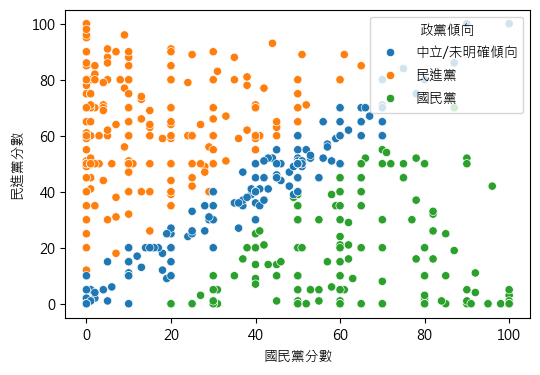

In [56]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='q40_1', y='q41_1', hue='政黨傾向')
plt.xlabel('國民黨分數')
plt.ylabel('民進黨分數')
plt.show()

In [86]:
prank = df.iloc[:, 141:178].drop(columns=['q21a_1', 'q21a_2', 'q21a_3', 'q21a_4', 'q21a_5', 'q21a_6', 'q21a_6_text'])

prank['q16'] = prank['q16'].replace({'否(跳答至18題)':0, '是':1})
prank['q18'] = prank['q18'].replace({'否(跳答至20(01)題)':0, '是':1})

acceptance_score = {'可以接受':5, '稍微可以接受':4, '普通':3, '有點不可以接受':2,'不可以接受':1}
acceptance_cols = ['q20_01_1', 'q20_02_1',
                   'q25_01_1', 'q25_02_1', 'q25_03_1', 'q25_04_1']
for col in acceptance_cols:
    prank[col] = pd.to_numeric(prank[col].replace(acceptance_score))

times_score = {'從來沒有':1, '很少':2, '有時':3, '經常':4}
times_cols = ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1',
              'q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_04_1', 'q23_05_1',
              'q24_01_1', 'q24_02_1', 'q24_03_1', 'q24_04_1', 'q24_05_1',
              'q26_01_1', 'q26_02_1', 'q26_03_1']
for col in times_cols:
    prank[col] = pd.to_numeric(prank[col].replace(times_score))



C:\Users\No\AppData\Local\Temp\ipykernel_16060\3929732169.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prank['q16'] = prank['q16'].replace({'否(跳答至18題)':0, '是':1})
C:\Users\No\AppData\Local\Temp\ipykernel_16060\3929732169.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prank['q18'] = prank['q18'].replace({'否(跳答至20(01)題)':0, '是':1})
C:\Users\No\AppData\Local\Temp\ipykernel_16060\3929732169.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

In [473]:
print(df.groupby('政黨傾向')['q20_01_1'].value_counts())


政黨傾向      q20_01_1
中立/未明確傾向  不可以接受       193
          有點不可以接受      59
          普通           28
          稍微可以接受        7
          可以接受          3
國民黨       不可以接受       106
          有點不可以接受      41
          普通           16
          可以接受          3
          稍微可以接受        3
民進黨       不可以接受       130
          有點不可以接受      67
          普通           22
          稍微可以接受        6
          可以接受          1
Name: count, dtype: int64


In [450]:
df.iloc[:, 178:198]

,q27_1,q28_1,q28_2,q28_3,q28_4,q28_4_text,q28_5,q29_1,q29_2,q29_3,q29_4,q29_5,q29_5_text,q30_1,q31_1,q32_1,q33_1,q34_1,q35_1,q36_1
0,普通,NaN,NaN,NaN,NaN,NaN,(05)沒有做過上述的抵制行為(跳答至37a題 ),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,普通,NaN,(02)拒絕觀看他們的發文或影音,NaN,NaN,NaN,NaN,NaN,(02)有不同的政治意識型態或價值觀,NaN,(04)做出不道德、不正當或不合法行為,NaN,NaN,普通,有時,普通,普通,非常少,非常少,很少
2,不想,NaN,NaN,NaN,NaN,NaN,(05)沒有做過上述的抵制行為(跳答至37a題 ),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,非常想,(01)取消關注他們的粉專或帳號,(02)拒絕觀看他們的發文或影音,(03)在網路上留言或發文指責他們,NaN,NaN,NaN,(01)歧視特定國家、種族或性別,(02)有不同的政治意識型態或價值觀,NaN,(04)做出不道德、不正當或不合法行為,NaN,NaN,完全沒有效,有時,普通,普通,非常少,有點多,有時
4,想,(01)取消關注他們的粉專或帳號,(02)拒絕觀看他們的發文或影音,NaN,NaN,NaN,NaN,(01)歧視特定國家、種族或性別,NaN,NaN,(04)做出不道德、不正當或不合法行為,NaN,NaN,有效,有時,普通,重要,非常少,有點多,很少
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,想,(01)取消關注他們的粉專或帳號,(02)拒絕觀看他們的發文或影音,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(04)做出不道德、不正當或不合法行為,NaN,NaN,普通,很少,嚴重,重要,有點少,非常多,很少
681,想,(01)取消關注他們的粉專或帳號,(02)拒絕觀看他們的發文或影音,(03)在網路上留言或發文指責他們,NaN,NaN,NaN,(01)歧視特定國家、種族或性別,(02)有不同的政治意識型態或價值觀,(03)不表態支持重要的社會議題,(04)做出不道德、不正當或不合法行為,NaN,NaN,普通,很少,普通,不重要,有點少,有點少,很少
682,普通,NaN,(02)拒絕觀看他們的發文或影音,NaN,NaN,NaN,NaN,(01)歧視特定國家、種族或性別,NaN,NaN,(04)做出不道德、不正當或不合法行為,NaN,NaN,普通,有時,普通,普通,普通,有點多,從來沒有
683,不想,(01)取消關注他們的粉專或帳號,(02)拒絕觀看他們的發文或影音,NaN,NaN,NaN,NaN,(01)歧視特定國家、種族或性別,NaN,(03)不表態支持重要的社會議題,(04)做出不道德、不正當或不合法行為,NaN,NaN,有效,從來沒有,嚴重,不重要,非常少,有點多,從來沒有


In [462]:
print(df.groupby('政黨傾向')['q28_1'].value_counts())
print(df.groupby('政黨傾向')['q28_2'].value_counts())
print(df.groupby('政黨傾向')['q28_3'].value_counts())
print(df.groupby('政黨傾向')['q28_4'].value_counts())
print(df.groupby('政黨傾向')['q28_4_text'].value_counts())
print(df.groupby('政黨傾向')['q28_5'].value_counts())

政黨傾向      q28_1           
中立/未明確傾向  (01)取消關注他們的粉專或帳號    152
國民黨       (01)取消關注他們的粉專或帳號     67
民進黨       (01)取消關注他們的粉專或帳號    130
Name: count, dtype: int64
政黨傾向      q28_2           
中立/未明確傾向  (02)拒絕觀看他們的發文或影音    157
國民黨       (02)拒絕觀看他們的發文或影音     89
民進黨       (02)拒絕觀看他們的發文或影音    155
Name: count, dtype: int64
政黨傾向      q28_3            
中立/未明確傾向  (03)在網路上留言或發文指責他們    10
國民黨       (03)在網路上留言或發文指責他們    14
民進黨       (03)在網路上留言或發文指責他們     7
Name: count, dtype: int64
政黨傾向      q28_4 
中立/未明確傾向  (04)其他    5
國民黨       (04)其他    2
民進黨       (04)其他    4
Name: count, dtype: int64
政黨傾向      q28_4_text                             
中立/未明確傾向  從來都不關注                                     1
          每個人有合法的言論自由，我只會拒絕觀看有問題違法的影片，不會ㄧ竿子打翻ㄧ條船。    1
          減少看他們的發文或影片                                1
          用選票來抵制                                     1
          看看就好,自己會有自己的判斷                             1
國民黨       看看就好                                       1
          若名人不自我反省就會抵制，但是通常名人都會願意出來面對錯誤      

In [457]:
print(df['q28_1'].value_counts())
print(df['q28_2'].value_counts())
print(df['q28_3'].value_counts())
print(df['q28_4'].value_counts())
print(df['q28_5'].value_counts())

q28_1
(01)取消關注他們的粉專或帳號    349
Name: count, dtype: int64
q28_2
(02)拒絕觀看他們的發文或影音    401
Name: count, dtype: int64
q28_3
(03)在網路上留言或發文指責他們    31
Name: count, dtype: int64
q28_4
(04)其他    11
Name: count, dtype: int64
q28_5
(05)沒有做過上述的抵制行為(跳答至37a題 )    196
Name: count, dtype: int64
